# Лабораторна робота №1
## Регресія, класифікація та ансамблеві методи
### Датасет: Food Delivery Time

**Цільова змінна:** `TARGET` — час доставки (хвилини)

**Кроки виконання:**
1. Підготовка даних (очищення, кодування, стандартизація)
2. Ймовірнісна регресія з довірчими інтервалами
3. Ансамблеві методи (Bagging, Boosting, Stacking)
4. Перехід від регресії до класифікації
5. Аналіз розподілу ймовірностей
6. Оптимізація класифікатора
7. Перетворення метрик між регресією та класифікацією

## 1. Імпорт бібліотек

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, KBinsDiscretizer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Регресійні моделі
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    StackingRegressor, RandomForestClassifier
)
import statsmodels.api as sm
from xgboost import XGBRegressor, XGBClassifier

# Класифікаційні моделі
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style='whitegrid', context='notebook')
print('Бібліотеки імпортовано успішно!')

Бібліотеки імпортовано успішно!


## 2. Завантаження та очищення даних

In [2]:
# Завантаження даних
df = pd.read_csv('food_delivery.csv')
print('Розмір датасету:', df.shape)
print('\nСтовпці:', df.columns.tolist())
display(df.head())
display(df.dtypes)

Розмір датасету: (10000, 17)

Стовпці: ['Traffic_Level', 'ID', 'Delivery_person_ID', 'weather_description', 'Type_of_order', 'Type_of_vehicle', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'temperature', 'humidity', 'precipitation', 'Distance (km)', 'TARGET']


,Traffic_Level,ID,Delivery_person_ID,weather_description,Type_of_order,Type_of_vehicle,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,temperature,humidity,precipitation,Distance (km),TARGET
0,High,70A2,CHENRES12DEL01,mist,Snack,scooter,32,4.6,12.972.793,80.249.982,13.012.793,80.289.982,26.55,87.0,0.0,9.89,43.45
1,High,95B4,RANCHIRES15DEL01,clear sky,Meal,scooter,33,4.7,23.369.746,8.533.982,23.479.746,8.544.982,17.51,69.0,0.0,19.11,3.816.666.667
2,High,CDCD,DEHRES17DEL01,clear sky,Snack,motorcycle,36,4.2,30.327.968,78.046.106,30.397.968,78.116.106,12.44,77.0,0.0,11.59,3.636.666.667
3,High,2784,PUNERES13DEL03,clear sky,Drinks,scooter,23,4.7,1.856.245,73.916.619,1.865.245,74.006.619,19.37,65.0,0.0,21.93,49.45
4,High,6F67,HYDRES14DEL01,overcast clouds,Snack,motorcycle,34,4.9,17.426.228,78.407.495,17.496.228,78.477.495,21.29,64.0,0.0,18.26,5.248.333.333


Traffic_Level                      str
ID                                 str
Delivery_person_ID                 str
weather_description                str
Type_of_order                      str
Type_of_vehicle                    str
Delivery_person_Age              int64
Delivery_person_Ratings        float64
Restaurant_latitude                str
Restaurant_longitude               str
Delivery_location_latitude         str
Delivery_location_longitude        str
temperature                    float64
humidity                       float64
precipitation                  float64
Distance (km)                  float64
TARGET                             str
dtype: object

In [3]:
print('Пропущені значення:')
print(df.isnull().sum())
print('\nОпис числових змінних:')
display(df.describe())

Пропущені значення:
Traffic_Level                  915
ID                               0
Delivery_person_ID               0
weather_description              5
Type_of_order                    0
Type_of_vehicle                  0
Delivery_person_Age              0
Delivery_person_Ratings          0
Restaurant_latitude              0
Restaurant_longitude             0
Delivery_location_latitude       0
Delivery_location_longitude      0
temperature                      5
humidity                         5
precipitation                    5
Distance (km)                  920
TARGET                         541
dtype: int64

Опис числових змінних:


,Delivery_person_Age,Delivery_person_Ratings,temperature,humidity,precipitation,Distance (km)
count,10000.000000,10000.000000,9995.000000,9995.000000,9995.000000,9080.000000
mean,29.522000,4.629370,22.936907,66.164882,0.016233,14.292747
std,5.700348,0.322941,3.379448,15.602939,0.074911,8.376254
min,15.000000,1.000000,6.770000,27.000000,0.000000,1.550000
25%,25.000000,4.500000,20.140000,54.000000,0.000000,7.620000
50%,29.000000,4.700000,23.000000,67.000000,0.000000,13.400000
75%,34.000000,4.800000,25.980000,81.000000,0.000000,19.610000
max,50.000000,6.000000,29.050000,94.000000,1.460000,59.840000


In [4]:
# --- Очищення даних ---

# Виправлення координат та TARGET (формат '12.972.793' → 12.972793)
def fix_coord(val):
    """Виправляє формат координат/чисел типу '12.972.793' → 12.972793"""
    try:
        return float(val)
    except (ValueError, TypeError):
        s = str(val).replace(' ', '')
        parts = s.split('.')
        if len(parts) > 2:
            return float(parts[0] + '.' + ''.join(parts[1:]))
        return np.nan

coord_cols = ['Restaurant_latitude','Restaurant_longitude',
              'Delivery_location_latitude','Delivery_location_longitude']
for col in coord_cols:
    if col in df.columns:
        df[col] = df[col].apply(fix_coord)

# Виправлення TARGET (теж може мати формат '3.816.666.667')
df['TARGET'] = df['TARGET'].apply(fix_coord)

# Видалення рядків із пропусками у цільовій змінній
df.dropna(subset=['TARGET'], inplace=True)

# Заповнення числових пропущених значень медіаною
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Заповнення категоріальних пропущених значень модою
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('Після очищення:', df.shape)
print('Пропуски після обробки:', df.isnull().sum().sum())

Після очищення: (9040, 17)
Пропуски після обробки: 0


In [5]:
# Виправлення масштабу TARGET:
# значення < 10 були '3.816.666.667' → 3.816... замість 38.16...
df['TARGET'] = df['TARGET'].apply(lambda x: x * 10 if x < 10 else x)

print('TARGET після виправлення:')
print(f'  min={df["TARGET"].min():.2f}, max={df["TARGET"].max():.2f}, mean={df["TARGET"].mean():.2f}')
print(f'  Кількість значень < 10: {(df["TARGET"] < 10).sum()}')

TARGET після виправлення:
  min=10.00, max=157.75, mean=38.32
  Кількість значень < 10: 0


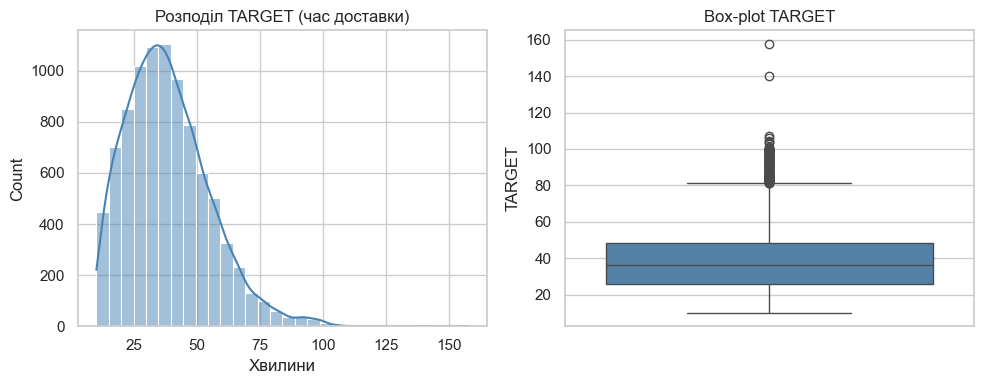

TARGET: min=10.00, max=157.75, mean=38.32


In [6]:
# Розподіл цільової змінної
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['TARGET'], bins=30, kde=True, color='steelblue')
plt.title('Розподіл TARGET (час доставки)')
plt.xlabel('Хвилини')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['TARGET'], color='steelblue')
plt.title('Box-plot TARGET')

plt.tight_layout()
plt.show()

print(f'TARGET: min={df["TARGET"].min():.2f}, max={df["TARGET"].max():.2f}, mean={df["TARGET"].mean():.2f}')

## 3. Підготовка ознак

In [7]:
# Видалення нерелевантних стовпців (ідентифікатори)
drop_cols = [col for col in ['ID', 'Delivery_person_ID'] if col in df.columns]
df_ml = df.drop(columns=drop_cols + ['TARGET'])
y = df['TARGET'].values

# Кодування категоріальних змінних (Label Encoding)
le_dict = {}
for col in df_ml.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))
    le_dict[col] = le
    print(f'{col}: {le.classes_}')

print('\nФорма матриці ознак:', df_ml.shape)

Traffic_Level: ['High' 'Low' 'Moderate' 'Very High' 'Very Low']
weather_description: ['broken clouds' 'clear sky' 'few clouds' 'fog' 'haze' 'mist'
 'moderate rain' 'overcast clouds' 'scattered clouds' 'smoke']
Type_of_order: ['Buffet' 'Drinks' 'Meal' 'Snack']
Type_of_vehicle: ['bicycle' 'electric_scooter' 'motorcycle' 'scooter']

Форма матриці ознак: (9040, 14)


In [8]:
# Розділення на тренувальну та тестову вибірки
X = df_ml.values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Тренувальних зразків: {X_train.shape[0]}')
print(f'Тестових зразків:     {X_test.shape[0]}')

# Стандартизація (fit тільки на тренувальних!)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Тренувальних зразків: 7232
Тестових зразків:     1808


## 4. Ймовірнісна регресія (без ансамблів)
### 4.1 Лінійна регресія + OLS довірчі інтервали

In [9]:
# --- Лінійна регресія (sklearn) ---
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f'Лінійна регресія — MAE: {mae_lr:.3f}, RMSE: {rmse_lr:.3f}, R²: {r2_lr:.3f}')

# --- OLS (statsmodels) для довірчих інтервалів ---
X_train_sm = sm.add_constant(X_train_sc, has_constant='add')
X_test_sm  = sm.add_constant(X_test_sc,  has_constant='add')
ols = sm.OLS(y_train, X_train_sm).fit()

pred_sm    = ols.get_prediction(X_test_sm)
pred_frame = pred_sm.summary_frame(alpha=0.05)

print('\nПерші 5 прогнозів з довірчими інтервалами:')
display(pred_frame[['mean','obs_ci_lower','obs_ci_upper']].head())

# --- OLS (statsmodels) для довірчих інтервалів ---
# Примітка: add_constant з has_constant='add' гарантує додавання стовпця
X_train_sm = sm.add_constant(X_train_sc, has_constant='add')
X_test_sm  = sm.add_constant(X_test_sc,  has_constant='add')
ols = sm.OLS(y_train, X_train_sm).fit()

pred_sm    = ols.get_prediction(X_test_sm)
pred_frame = pred_sm.summary_frame(alpha=0.05)

print(f'Лінійна регресія — MAE: {mae_lr:.3f}, RMSE: {rmse_lr:.3f}, R²: {r2_lr:.3f}')
print('\nПерші 5 прогнозів з довірчими інтервалами:')
display(pred_frame[['mean','obs_ci_lower','obs_ci_upper']].head())

Лінійна регресія — MAE: 6.603, RMSE: 9.684, R²: 0.629

Перші 5 прогнозів з довірчими інтервалами:


,mean,obs_ci_lower,obs_ci_upper
0,49.633097,27.572219,71.693974
1,54.905062,32.847193,76.962932
2,56.988574,34.929291,79.047857
3,29.396550,7.342748,51.450353
4,28.182182,6.117648,50.246716


Лінійна регресія — MAE: 6.603, RMSE: 9.684, R²: 0.629

Перші 5 прогнозів з довірчими інтервалами:


,mean,obs_ci_lower,obs_ci_upper
0,49.633097,27.572219,71.693974
1,54.905062,32.847193,76.962932
2,56.988574,34.929291,79.047857
3,29.396550,7.342748,51.450353
4,28.182182,6.117648,50.246716


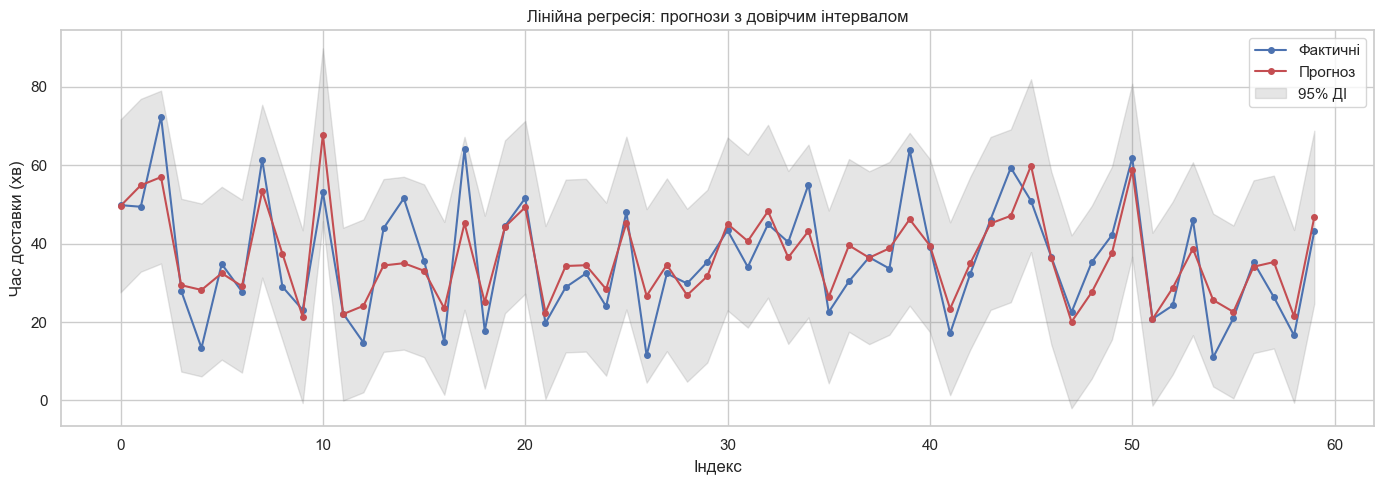

In [10]:
# Візуалізація: лінійна регресія + 95% ДІ (перші 60 зразків)
n = 60
idx = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(idx, y_test[:n],        'bo-', ms=4, label='Фактичні')
plt.plot(idx, y_pred_lr[:n],     'ro-', ms=4, label='Прогноз')
plt.fill_between(idx,
    pred_frame['obs_ci_lower'].values[:n],
    pred_frame['obs_ci_upper'].values[:n],
    alpha=0.2, color='gray', label='95% ДІ')
plt.title('Лінійна регресія: прогнози з довірчим інтервалом')
plt.xlabel('Індекс'); plt.ylabel('Час доставки (хв)')
plt.legend(); plt.tight_layout(); plt.show()

### 4.2 Ridge та Lasso регресія

In [11]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f'{name:35s} — MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}')
    return mae, rmse, r2

# Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)
reg_metrics('Ridge (alpha=1.0)', y_test, y_pred_ridge)

# Lasso
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_sc, y_train)
y_pred_lasso = lasso.predict(X_test_sc)
reg_metrics('Lasso (alpha=0.1)', y_test, y_pred_lasso)

# Decision Tree (без ансамблю)
dtr = DecisionTreeRegressor(max_depth=7, random_state=42)
dtr.fit(X_train_sc, y_train)
y_pred_dtr = dtr.predict(X_test_sc)
reg_metrics('Decision Tree Regressor (depth=7)', y_test, y_pred_dtr)

Ridge (alpha=1.0)                   — MAE: 6.605, RMSE: 9.687, R²: 0.628
Lasso (alpha=0.1)                   — MAE: 6.631, RMSE: 9.715, R²: 0.626
Decision Tree Regressor (depth=7)   — MAE: 4.046, RMSE: 7.331, R²: 0.787


(4.0461523949075175, np.float64(7.330536678515161), 0.7872340519891067)

### 4.3 Оптимізація Ridge через GridSearchCV

In [12]:
param_grid_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
gs_ridge = GridSearchCV(Ridge(), param_grid_ridge, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
gs_ridge.fit(X_train_sc, y_train)

print('Найкращий alpha:', gs_ridge.best_params_)
y_pred_ridge_opt = gs_ridge.best_estimator_.predict(X_test_sc)
reg_metrics('Ridge (оптимізований)', y_test, y_pred_ridge_opt)

Найкращий alpha: {'alpha': 0.1}
Ridge (оптимізований)               — MAE: 6.603, RMSE: 9.684, R²: 0.629


(6.603119896808511, np.float64(9.684327583307793), 0.6286618891408661)

## 5. Ансамблеві методи
### 5.1 Bagging — Random Forest

In [13]:
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_sc, y_train)
y_pred_rf = rf_reg.predict(X_test_sc)

mae_rf, rmse_rf, r2_rf = reg_metrics('Random Forest (Bagging)', y_test, y_pred_rf)

# Інтервали через прогнози окремих дерев
tree_preds = np.array([t.predict(X_test_sc) for t in rf_reg.estimators_]).T
rf_lo = np.percentile(tree_preds, 2.5, axis=1)
rf_hi = np.percentile(tree_preds, 97.5, axis=1)

# Покриття інтервалу
coverage = np.mean((y_test >= rf_lo) & (y_test <= rf_hi))
print(f'Покриття 95% інтервалу (RF): {coverage:.3f}')

Random Forest (Bagging)             — MAE: 2.990, RMSE: 5.346, R²: 0.887
Покриття 95% інтервалу (RF): 0.914


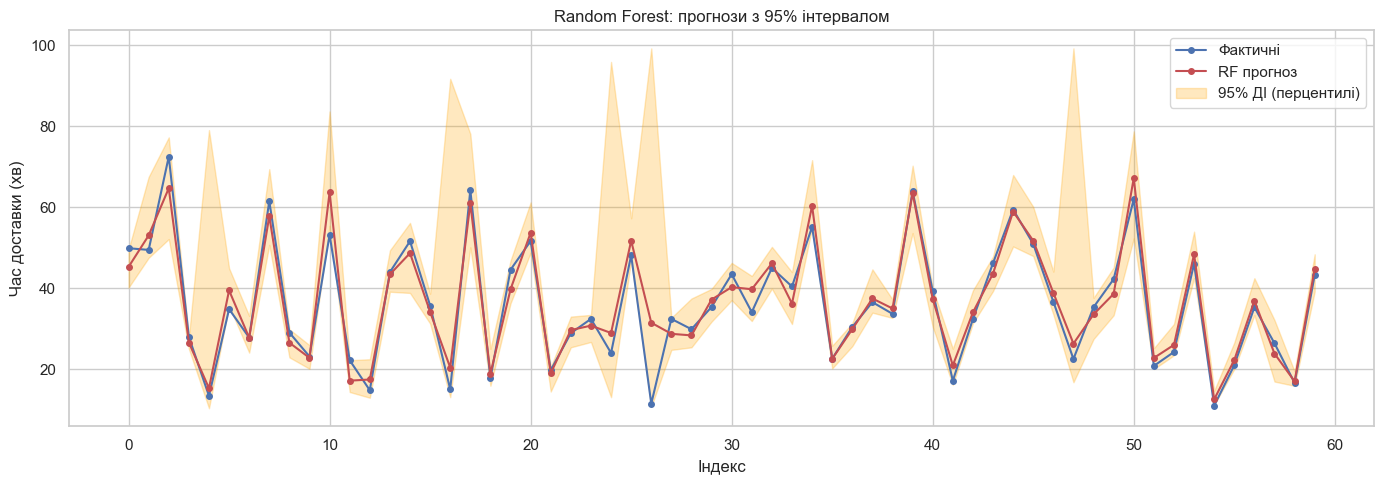

In [14]:
# Візуалізація Random Forest + інтервали
n = 60; idx = np.arange(n)
plt.figure(figsize=(14, 5))
plt.plot(idx, y_test[:n],    'bo-', ms=4, label='Фактичні')
plt.plot(idx, y_pred_rf[:n], 'ro-', ms=4, label='RF прогноз')
plt.fill_between(idx, rf_lo[:n], rf_hi[:n], alpha=0.25, color='orange', label='95% ДІ (перцентилі)')
plt.title('Random Forest: прогнози з 95% інтервалом')
plt.xlabel('Індекс'); plt.ylabel('Час доставки (хв)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Boosting — Gradient Boosting та XGBoost

In [15]:
# Gradient Boosting (середній прогноз)
gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    max_depth=4, random_state=42)
gb_reg.fit(X_train_sc, y_train)
y_pred_gb = gb_reg.predict(X_test_sc)
mae_gb, rmse_gb, r2_gb = reg_metrics('Gradient Boosting', y_test, y_pred_gb)

# Квантильний GB для інтервалів
gb_lo_m = GradientBoostingRegressor(loss='quantile', alpha=0.025,
                                     n_estimators=200, learning_rate=0.05, random_state=42)
gb_hi_m = GradientBoostingRegressor(loss='quantile', alpha=0.975,
                                     n_estimators=200, learning_rate=0.05, random_state=42)
gb_lo_m.fit(X_train_sc, y_train); gb_lo = gb_lo_m.predict(X_test_sc)
gb_hi_m.fit(X_train_sc, y_train); gb_hi = gb_hi_m.predict(X_test_sc)

coverage_gb = np.mean((y_test >= gb_lo) & (y_test <= gb_hi))
print(f'Покриття 95% інтервалу (GB): {coverage_gb:.3f}')

# XGBoost
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.05,
                        max_depth=4, random_state=42, verbosity=0)
xgb_reg.fit(X_train_sc, y_train)
y_pred_xgb = xgb_reg.predict(X_test_sc)
reg_metrics('XGBoost', y_test, y_pred_xgb)

Gradient Boosting                   — MAE: 3.434, RMSE: 6.086, R²: 0.853
Покриття 95% інтервалу (GB): 0.957
XGBoost                             — MAE: 3.407, RMSE: 6.091, R²: 0.853


(3.407083267903795, np.float64(6.09101226707166), 0.8531041492037981)

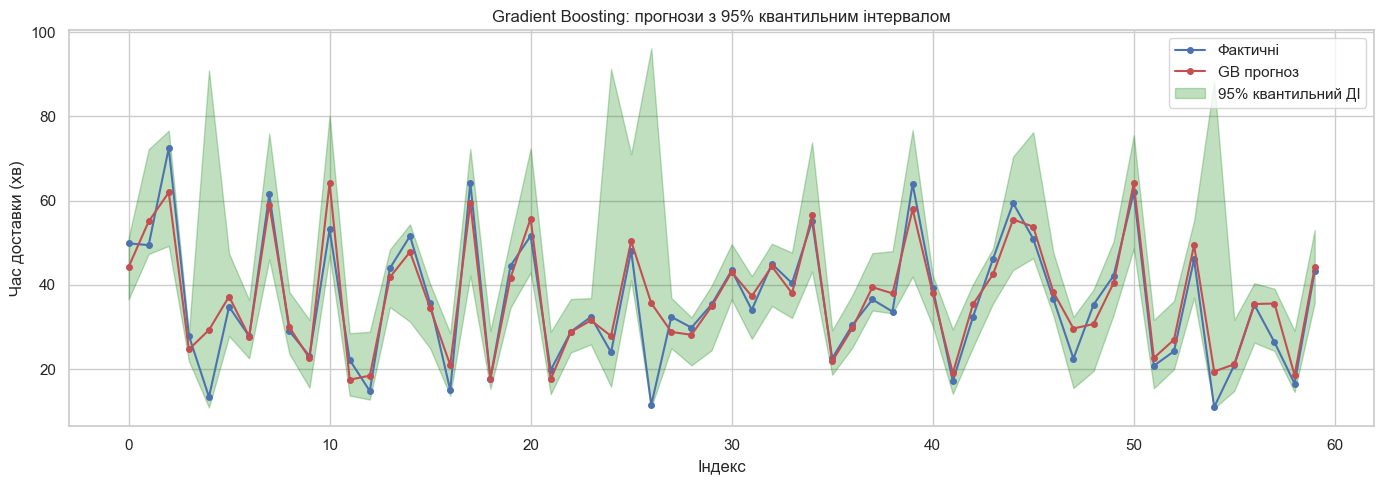

In [16]:
# Візуалізація GB + квантильні інтервали
n = 60; idx = np.arange(n)
plt.figure(figsize=(14, 5))
plt.plot(idx, y_test[:n],    'bo-', ms=4, label='Фактичні')
plt.plot(idx, y_pred_gb[:n], 'ro-', ms=4, label='GB прогноз')
plt.fill_between(idx, gb_lo[:n], gb_hi[:n], alpha=0.25, color='green', label='95% квантильний ДІ')
plt.title('Gradient Boosting: прогнози з 95% квантильним інтервалом')
plt.xlabel('Індекс'); plt.ylabel('Час доставки (хв)')
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Stacking

In [17]:
from sklearn.ensemble import StackingRegressor

base_estimators = [
    ('ridge', Ridge(alpha=1.0)),
    ('dtr',   DecisionTreeRegressor(max_depth=5, random_state=42)),
    ('rf',    RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))
]
meta_model = GradientBoostingRegressor(n_estimators=100, random_state=42)

stacking = StackingRegressor(estimators=base_estimators, final_estimator=meta_model, cv=5, n_jobs=-1)
stacking.fit(X_train_sc, y_train)
y_pred_stack = stacking.predict(X_test_sc)
reg_metrics('Stacking', y_test, y_pred_stack)

Stacking                            — MAE: 3.169, RMSE: 5.767, R²: 0.868


(3.1690042082970042, np.float64(5.767365318262975), 0.868300082284915)

,Модель,MAE,RMSE,R²
4,Random Forest,2.9895,5.3460,0.8868
7,Stacking,3.1690,5.7674,0.8683
6,XGBoost,3.4071,6.0910,0.8531
5,Gradient Boosting,3.4335,6.0856,0.8534
3,Decision Tree,4.0462,7.3305,0.7872
0,Лінійна регресія,6.6028,9.6840,0.6287
1,Ridge (оптим.),6.6031,9.6843,0.6287
2,Lasso,6.6311,9.7152,0.6263


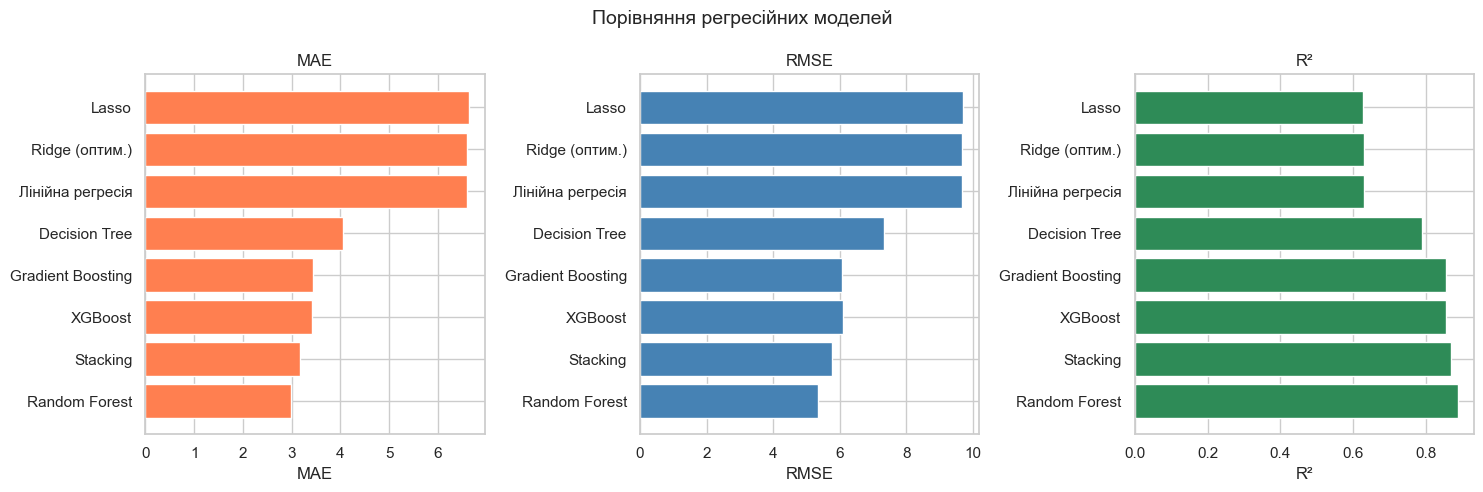

In [18]:
# Зведена таблиця результатів регресії
results_reg = pd.DataFrame({
    'Модель': ['Лінійна регресія','Ridge (оптим.)','Lasso','Decision Tree','Random Forest','Gradient Boosting','XGBoost','Stacking'],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge_opt),
        mean_absolute_error(y_test, y_pred_lasso),
        mean_absolute_error(y_test, y_pred_dtr),
        mae_rf, mae_gb,
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_stack)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge_opt)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso)),
        np.sqrt(mean_squared_error(y_test, y_pred_dtr)),
        rmse_rf, rmse_gb,
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_stack))
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge_opt),
        r2_score(y_test, y_pred_lasso),
        r2_score(y_test, y_pred_dtr),
        r2_rf, r2_gb,
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_stack)
    ]
}).round(4)

results_reg = results_reg.sort_values('MAE')
display(results_reg)

# Графік порівняння
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, c in zip(axes, ['MAE','RMSE','R²'], ['coral','steelblue','seagreen']):
    ax.barh(results_reg['Модель'], results_reg[col], color=c)
    ax.set_title(col); ax.set_xlabel(col)
plt.suptitle('Порівняння регресійних моделей', fontsize=14)
plt.tight_layout(); plt.show()

## 6. Перехід від регресії до класифікації
### 6.1 Дискретизація на 4 класи (equal-width)

In [19]:
N_BINS = 4
kbd4 = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='quantile', subsample=None)
# kbd4 = KBinsDiscretizer(n_bins=N_BINS, encode='ordinal', strategy='uniform', subsample=None)
y_train_c4 = kbd4.fit_transform(y_train.reshape(-1,1)).astype(int).ravel()
y_test_c4  = kbd4.transform(y_test.reshape(-1,1)).astype(int).ravel()

edges = kbd4.bin_edges_[0]
print('Межі класів (4 bins):', np.round(edges, 2))
print('Розподіл класів (тренування):')
print(pd.Series(y_train_c4).value_counts().sort_index())

Межі класів (4 bins): [ 10.    26.    36.57  48.4  157.75]
Розподіл класів (тренування):
0    1808
1    1807
2    1809
3    1808
Name: count, dtype: int64


Логістична регресія (4 класи): Accuracy=0.751, Precision=0.759, Recall=0.751, F1=0.747


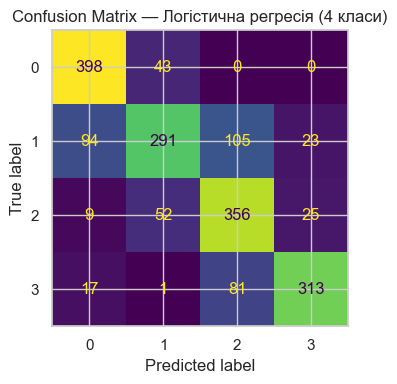

In [20]:
# Функція оцінки класифікаційних метрик
def clf_metrics(name, y_true, y_pred, show_matrix=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    print(f'{name}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}')
    if show_matrix:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        ConfusionMatrixDisplay(cm).plot(ax=ax, colorbar=False)
        ax.set_title(f'Confusion Matrix — {name}')
        plt.tight_layout(); plt.show()
    return acc, prec, rec, f1

# --- Логістична регресія ---
logreg = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
logreg.fit(X_train_sc, y_train_c4)
y_pred_logreg = logreg.predict(X_test_sc)
acc_lr4, *_ = clf_metrics('Логістична регресія (4 класи)', y_test_c4, y_pred_logreg)

Decision Tree (4 класи): Accuracy=0.815, Precision=0.828, Recall=0.815, F1=0.813


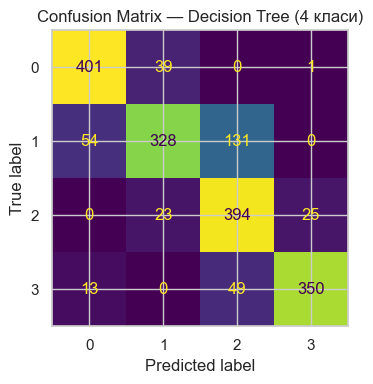

In [21]:
# --- Decision Tree Classifier ---
dtc = DecisionTreeClassifier(max_depth=7, random_state=42)
dtc.fit(X_train_sc, y_train_c4)
y_pred_dtc = dtc.predict(X_test_sc)
acc_dtc4, *_ = clf_metrics('Decision Tree (4 класи)', y_test_c4, y_pred_dtc)

XGBoost Classifier (4 класи): Accuracy=0.839, Precision=0.848, Recall=0.839, F1=0.840


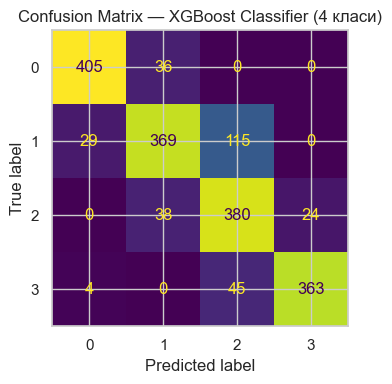

In [22]:
# --- XGBoost Classifier ---
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.05,
                         max_depth=4, random_state=42, verbosity=0)
xgb_clf.fit(X_train_sc, y_train_c4)
y_pred_xgbc = xgb_clf.predict(X_test_sc)
acc_xgb4, *_ = clf_metrics('XGBoost Classifier (4 класи)', y_test_c4, y_pred_xgbc)

### 6.2 Дискретизація на 6 класів (порівняння)

Межі класів (6 bins): [ 10.    21.9   29.72  36.57  44.02  54.28 157.75]
Розподіл класів (тренування): 0    1201
1    1209
2    1205
3    1202
4    1209
5    1206
Name: count, dtype: int64
Класи після перемапування: [0 1 2 3 4 5]
XGBoost (6 класів): Accuracy=0.732, Precision=0.731, Recall=0.732, F1=0.727


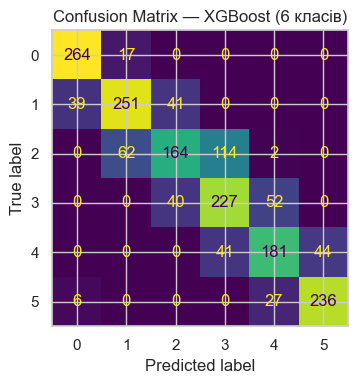


Порівняння: XGBoost 4 класи → Accuracy=0.839 | 6 класів → Accuracy=0.732


In [23]:
N_BINS6 = 6
kbd6 = KBinsDiscretizer(n_bins=N_BINS6, encode='ordinal', strategy='quantile', subsample=None)
# kbd6 = KBinsDiscretizer(n_bins=N_BINS6, encode='ordinal', strategy='uniform', subsample=None)
y_train_c6 = kbd6.fit_transform(y_train.reshape(-1,1)).astype(int).ravel()
y_test_c6  = kbd6.transform(y_test.reshape(-1,1)).astype(int).ravel()

print('Межі класів (6 bins):', np.round(kbd6.bin_edges_[0], 2))
print('Розподіл класів (тренування):', pd.Series(y_train_c6).value_counts().sort_index())

# Перемапування класів щоб були послідовними (0,1,2,... без пропусків)
unique_classes = np.unique(y_train_c6)
remap = {old: new for new, old in enumerate(unique_classes)}
y_train_c6 = np.array([remap[c] for c in y_train_c6])
y_test_c6  = np.array([remap.get(c, -1) for c in y_test_c6])

# Видаляємо тестові зразки з класом -1 (якщо є)
mask = y_test_c6 != -1
X_test_sc6 = X_test_sc[mask]
y_test_c6  = y_test_c6[mask]

print('Класи після перемапування:', np.unique(y_train_c6))

xgb_clf6 = XGBClassifier(n_estimators=200, learning_rate=0.05,
                          max_depth=4, random_state=42, verbosity=0)
xgb_clf6.fit(X_train_sc, y_train_c6)
y_pred_xgb6 = xgb_clf6.predict(X_test_sc6)
acc_xgb6, *_ = clf_metrics('XGBoost (6 класів)', y_test_c6, y_pred_xgb6)

print(f'\nПорівняння: XGBoost 4 класи → Accuracy={acc_xgb4:.3f} | 6 класів → Accuracy={acc_xgb6:.3f}')

## 7. Розподіл ймовірностей у класифікації
### 7.1 Гістограми ймовірностей (Random Forest Classifier)

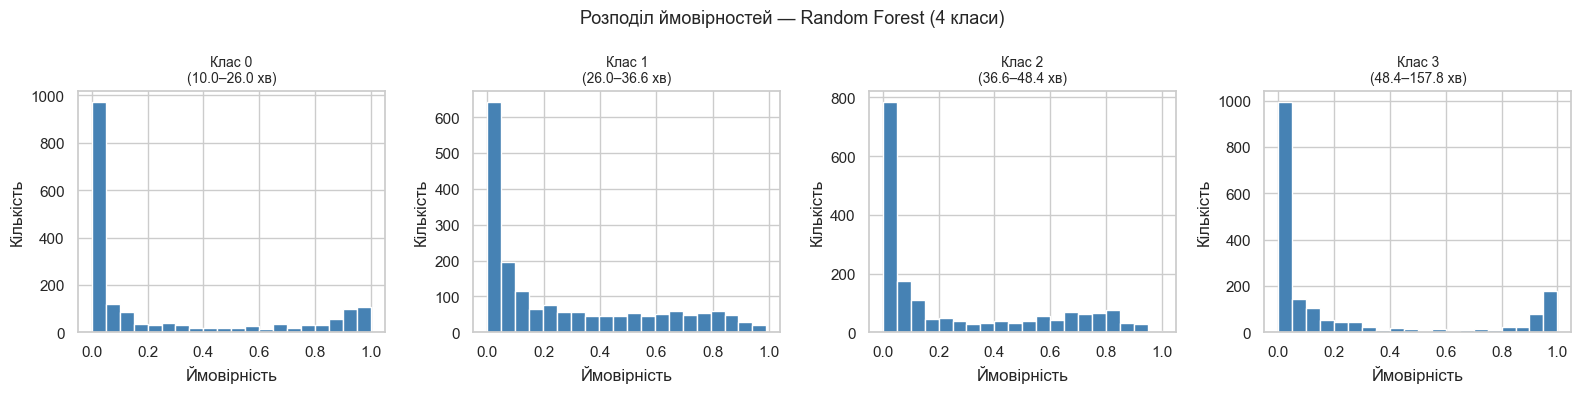

In [24]:
# Random Forest Classifier (4 класи)
rfc = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfc.fit(X_train_sc, y_train_c4)
y_proba_rfc = rfc.predict_proba(X_test_sc)

# Гістограми ймовірностей для кожного класу
fig, axes = plt.subplots(1, N_BINS, figsize=(16, 4))
class_labels = [f'{edges[i]:.1f}–{edges[i+1]:.1f} хв' for i in range(N_BINS)]

for i, ax in enumerate(axes):
    ax.hist(y_proba_rfc[:, i], bins=20, color='steelblue', edgecolor='white')
    ax.set_title(f'Клас {i}\n({class_labels[i]})', fontsize=10)
    ax.set_xlabel('Ймовірність'); ax.set_ylabel('Кількість')

plt.suptitle('Розподіл ймовірностей — Random Forest (4 класи)', fontsize=13)
plt.tight_layout(); plt.show()

### 7.2 Overfitting vs Underfitting через ймовірності

In [25]:
# Overfitting: Decision Tree без обмежень
dtc_overfit = DecisionTreeClassifier(max_depth=None, random_state=42)
dtc_overfit.fit(X_train_sc, y_train_c4)
proba_over = dtc_overfit.predict_proba(X_test_sc)
print(f'DT без обмежень — Train acc: {accuracy_score(y_train_c4, dtc_overfit.predict(X_train_sc)):.3f} | Test acc: {accuracy_score(y_test_c4, dtc_overfit.predict(X_test_sc)):.3f}')

# Underfitting: Decision Tree з глибиною 1
dtc_underfit = DecisionTreeClassifier(max_depth=1, random_state=42)
dtc_underfit.fit(X_train_sc, y_train_c4)
proba_under = dtc_underfit.predict_proba(X_test_sc)
print(f'DT глибина=1    — Train acc: {accuracy_score(y_train_c4, dtc_underfit.predict(X_train_sc)):.3f} | Test acc: {accuracy_score(y_test_c4, dtc_underfit.predict(X_test_sc)):.3f}')

# Нормальна модель
dtc_normal = DecisionTreeClassifier(max_depth=7, random_state=42)
dtc_normal.fit(X_train_sc, y_train_c4)
proba_norm = dtc_normal.predict_proba(X_test_sc)
print(f'DT глибина=7    — Train acc: {accuracy_score(y_train_c4, dtc_normal.predict(X_train_sc)):.3f} | Test acc: {accuracy_score(y_test_c4, dtc_normal.predict(X_test_sc)):.3f}')

DT без обмежень — Train acc: 1.000 | Test acc: 0.796
DT глибина=1    — Train acc: 0.472 | Test acc: 0.455
DT глибина=7    — Train acc: 0.853 | Test acc: 0.815


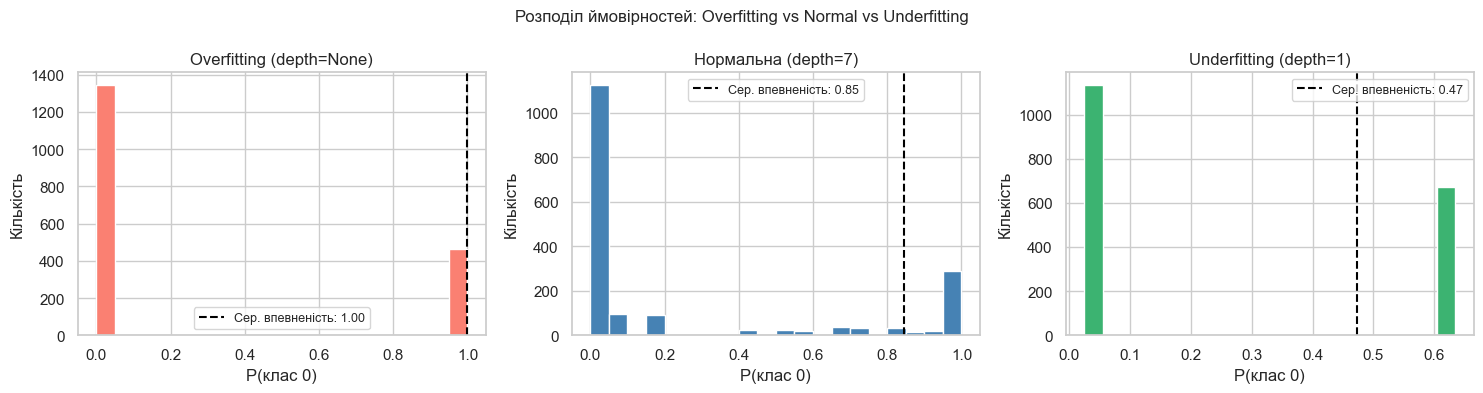


Висновок:
  Overfitting — середня максимальна ймовірність: 1.000 (висока впевненість, але помилки на тесті)
  Normal      — середня максимальна ймовірність: 0.845
  Underfitting— середня максимальна ймовірність: 0.473 (рівномірний розподіл, низька впевненість)


In [26]:
# Порівняння розподілу ймовірностей (клас 0)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
titles  = ['Overfitting (depth=None)', 'Нормальна (depth=7)', 'Underfitting (depth=1)']
probas  = [proba_over, proba_norm, proba_under]
colors  = ['salmon', 'steelblue', 'mediumseagreen']

for ax, title, proba, color in zip(axes, titles, probas, colors):
    ax.hist(proba[:, 0], bins=20, color=color, edgecolor='white')
    ax.set_title(title); ax.set_xlabel('P(клас 0)'); ax.set_ylabel('Кількість')
    mean_p = proba.max(axis=1).mean()
    ax.axvline(mean_p, color='black', linestyle='--', label=f'Сер. впевненість: {mean_p:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Розподіл ймовірностей: Overfitting vs Normal vs Underfitting', fontsize=12)
plt.tight_layout(); plt.show()

print('\nВисновок:')
print(f'  Overfitting — середня максимальна ймовірність: {proba_over.max(axis=1).mean():.3f} (висока впевненість, але помилки на тесті)')
print(f'  Normal      — середня максимальна ймовірність: {proba_norm.max(axis=1).mean():.3f}')
print(f'  Underfitting— середня максимальна ймовірність: {proba_under.max(axis=1).mean():.3f} (рівномірний розподіл, низька впевненість)')

## 8. Оптимізація класифікатора (GridSearchCV)
### Обираємо 4 класи як кращий варіант дискретизації

Найкращі параметри Decision Tree: {'max_depth': 7, 'min_samples_leaf': 3, 'min_samples_split': 2}
CV accuracy: 0.8330
Decision Tree (оптимізований): Accuracy=0.815, Precision=0.828, Recall=0.815, F1=0.814


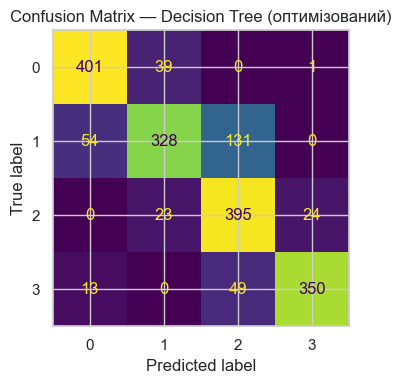

(0.8152654867256637,
 0.8282520212409112,
 0.8152654867256637,
 0.8139186437746794)

In [27]:
param_grid_dtc = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 3, 5]
}

gs_dtc = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dtc, cv=5, scoring='accuracy', n_jobs=-1
)
gs_dtc.fit(X_train_sc, y_train_c4)

print('Найкращі параметри Decision Tree:', gs_dtc.best_params_)
print(f'CV accuracy: {gs_dtc.best_score_:.4f}')

y_pred_dtc_opt = gs_dtc.best_estimator_.predict(X_test_sc)
clf_metrics('Decision Tree (оптимізований)', y_test_c4, y_pred_dtc_opt)

In [28]:
# Зведена таблиця класифікації
clf_results = []
for name, y_pred in [
    ('Логістична регресія', y_pred_logreg),
    ('Decision Tree (базовий)', y_pred_dtc),
    ('Decision Tree (оптим.)', y_pred_dtc_opt),
    ('XGBoost', y_pred_xgbc)
]:
    clf_results.append({
        'Модель': name,
        'Accuracy':  round(accuracy_score(y_test_c4, y_pred), 4),
        'Precision': round(precision_score(y_test_c4, y_pred, average='weighted', zero_division=0), 4),
        'Recall':    round(recall_score(y_test_c4, y_pred, average='weighted', zero_division=0), 4),
        'F1':        round(f1_score(y_test_c4, y_pred, average='weighted', zero_division=0), 4),
    })

display(pd.DataFrame(clf_results).sort_values('Accuracy', ascending=False))

,Модель,Accuracy,Precision,Recall,F1
3,XGBoost,0.8390,0.8477,0.8390,0.8401
2,Decision Tree (оптим.),0.8153,0.8283,0.8153,0.8139
1,Decision Tree (базовий),0.8147,0.8276,0.8147,0.8134
0,Логістична регресія,0.7511,0.7589,0.7511,0.7474


## 9. Перетворення метрик між регресією та класифікацією

In [29]:
# Найкраща регресія — беремо RF
best_mae  = mae_rf
best_rmse = rmse_rf

# Найкращий класифікатор — XGBoost
best_acc  = accuracy_score(y_test_c4, y_pred_xgbc)

R = y_test.max() - y_test.min()   # розмах цільової змінної
w = R / N_BINS                     # ширина класу

print('=== Вихідні дані ===')
print(f'Random Forest:  MAE={best_mae:.4f}, RMSE={best_rmse:.4f}')
print(f'XGBoost clf:    Accuracy={best_acc:.4f}')
print(f'Розмах R={R:.4f}, Ширина класу w={w:.4f}')

print('\n=== Формульні перетворення ===')
acc_from_mae = 1 - (best_mae / w)
print(f'MAE → Accuracy:  1 - {best_mae:.4f}/{w:.4f} = {acc_from_mae:.4f}')

mae_from_acc = (1 - best_acc) * R + w / 2
print(f'Accuracy → MAE:  (1-{best_acc:.4f})*{R:.4f} + {w:.4f}/2 = {mae_from_acc:.4f}')

=== Вихідні дані ===
Random Forest:  MAE=2.9895, RMSE=5.3460
XGBoost clf:    Accuracy=0.8390
Розмах R=95.8500, Ширина класу w=23.9625

=== Формульні перетворення ===
MAE → Accuracy:  1 - 2.9895/23.9625 = 0.8752
Accuracy → MAE:  (1-0.8390)*95.8500 + 23.9625/2 = 27.4084


In [30]:
# Дискретизація прогнозів регресії (RF) → точність
reg_pred_class = kbd4.transform(y_pred_rf.reshape(-1,1)).astype(int).ravel()
acc_reg_disc = accuracy_score(y_test_c4, reg_pred_class)
print(f'Точність дискретизованих прогнозів RF: {acc_reg_disc:.4f}')

# MAE через середні значення класів
class_means = {}
for cls in range(N_BINS):
    vals = y_train[y_train_c4 == cls]
    class_means[cls] = vals.mean() if len(vals) > 0 else (edges[cls] + edges[cls+1]) / 2

mapped_pred = np.array([class_means[c] for c in reg_pred_class])
mae_mapped  = mean_absolute_error(y_test, mapped_pred)
print(f'MAE після заміни середніми значеннями класів: {mae_mapped:.4f}')

Точність дискретизованих прогнозів RF: 0.8330
MAE після заміни середніми значеннями класів: 5.0697


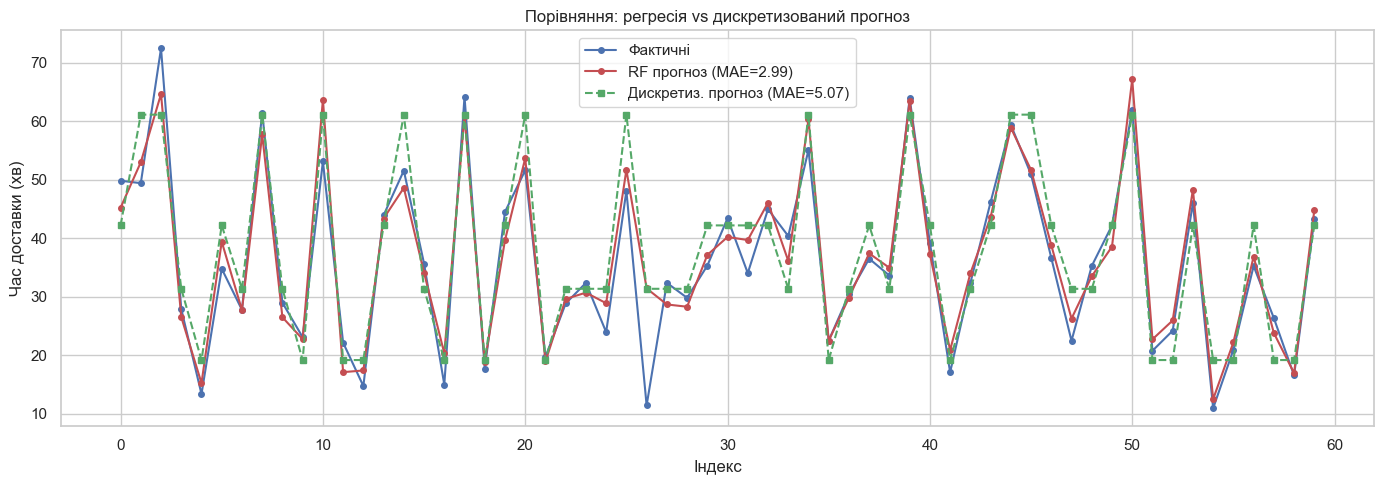


=== Підсумки ===
Регресія (Random Forest):     MAE=2.9895, RMSE=5.3460, R²=0.8868
Класифікація (XGBoost):       Accuracy=0.8390
Дискретизація прогнозів RF:   Accuracy=0.8330, MAE=5.0697
Формула MAE→Acc:              0.8752
Формула Acc→MAE:              27.4084

Висновок: Регресія дає більш точний прогноз у числовому вимірі.
Класифікація спрощує задачу, але втрачає деталізацію.
Ансамблеві методи (RF, XGBoost, Stacking) суттєво перевищують базові моделі.


In [31]:
# Фінальне порівняння
n = 60; idx = np.arange(n)
plt.figure(figsize=(14, 5))
plt.plot(idx, y_test[:n],       'bo-', ms=4, label='Фактичні')
plt.plot(idx, y_pred_rf[:n],    'ro-', ms=4, label=f'RF прогноз (MAE={best_mae:.2f})')
plt.plot(idx, mapped_pred[:n],  'gs--', ms=4, label=f'Дискретиз. прогноз (MAE={mae_mapped:.2f})')
plt.title('Порівняння: регресія vs дискретизований прогноз')
plt.xlabel('Індекс'); plt.ylabel('Час доставки (хв)')
plt.legend(); plt.tight_layout(); plt.show()

print('\n=== Підсумки ===')
print(f'Регресія (Random Forest):     MAE={best_mae:.4f}, RMSE={best_rmse:.4f}, R²={r2_rf:.4f}')
print(f'Класифікація (XGBoost):       Accuracy={best_acc:.4f}')
print(f'Дискретизація прогнозів RF:   Accuracy={acc_reg_disc:.4f}, MAE={mae_mapped:.4f}')
print(f'Формула MAE→Acc:              {acc_from_mae:.4f}')
print(f'Формула Acc→MAE:              {mae_from_acc:.4f}')
print('\nВисновок: Регресія дає більш точний прогноз у числовому вимірі.')
print('Класифікація спрощує задачу, але втрачає деталізацію.')
print('Ансамблеві методи (RF, XGBoost, Stacking) суттєво перевищують базові моделі.')

Топ-10 ознак, що найбільше визначають час доставки:


,Ознака,Важливість
13,Distance (km),0.5475
0,Traffic_Level,0.1901
2,Type_of_order,0.0764
10,temperature,0.0314
11,humidity,0.0234
1,weather_description,0.0215
8,Delivery_location_latitude,0.0194
9,Delivery_location_longitude,0.0180
4,Delivery_person_Age,0.0179
6,Restaurant_latitude,0.0175


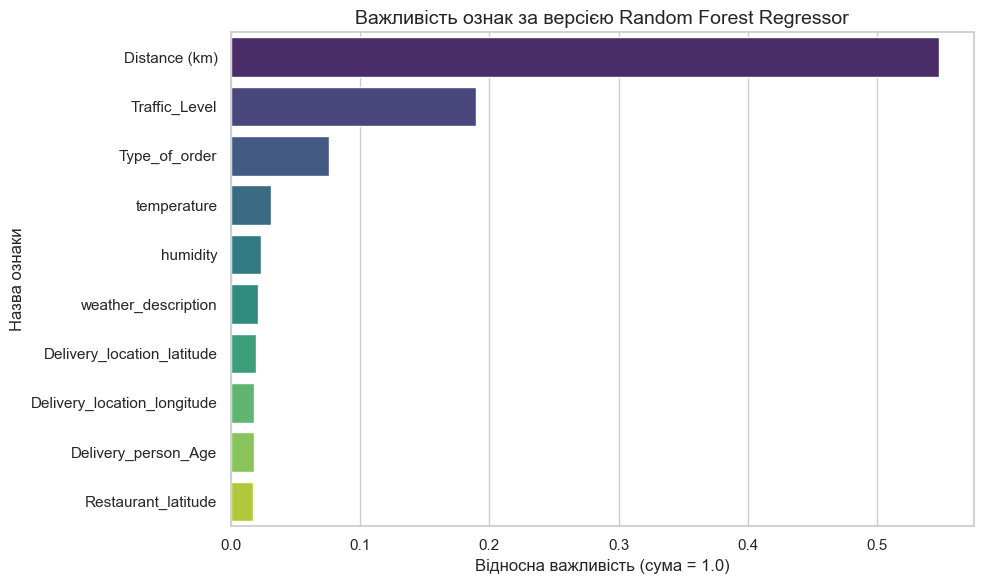

In [32]:
importances = rf_reg.feature_importances_
feature_names = df_ml.columns

feature_importance_df = pd.DataFrame({
    'Ознака': feature_names,
    'Важливість': importances
}).sort_values(by='Важливість', ascending=False)

print("Топ-10 ознак, що найбільше визначають час доставки:")
display(feature_importance_df.head(10).round(4))

plt.figure(figsize=(10, 6))
sns.barplot(
    x='Важливість', 
    y='Ознака', 
    data=feature_importance_df.head(10), 
    palette='viridis'
)

plt.title('Важливість ознак за версією Random Forest Regressor', fontsize=14)
plt.xlabel('Відносна важливість (сума = 1.0)', fontsize=12)
plt.ylabel('Назва ознаки', fontsize=12)
plt.tight_layout()
plt.show()